In [ ]:
# Loading library python
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

In [ ]:
# Read dataset
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('citrus.csv')
df.head()

Saving citrus.csv to citrus.csv


,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9


In [ ]:
# Describe
df.describe()

,diameter,weight,red,green,blue
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,9.975685,175.050792,153.847800,76.010600,11.363200
std,1.947844,29.212119,10.432954,11.708433,9.061275
min,2.960000,86.760000,115.000000,31.000000,2.000000
25%,8.460000,152.220000,147.000000,68.000000,2.000000
50%,9.980000,174.985000,154.000000,76.000000,10.000000
75%,11.480000,197.722500,161.000000,84.000000,17.000000
max,16.450000,261.510000,192.000000,116.000000,56.000000


In [ ]:
# Melihat jumlah data per kelas
df['name'].value_counts()

,count
name,
orange,5000
grapefruit,5000


**Insight:**
- Terdapat sebanyak 10.000 sampel yang ditemukan, sampel tersebut terbagi sempurna yakni 5.000 sampel orange dan 5.000 sampel grapefruit (perfectly balanced, tidak ada class imbalance).
- Fitur yang tersedia dalam dataset ini terdapat diameter, weight, red, green, blue (nilai warna RGB).

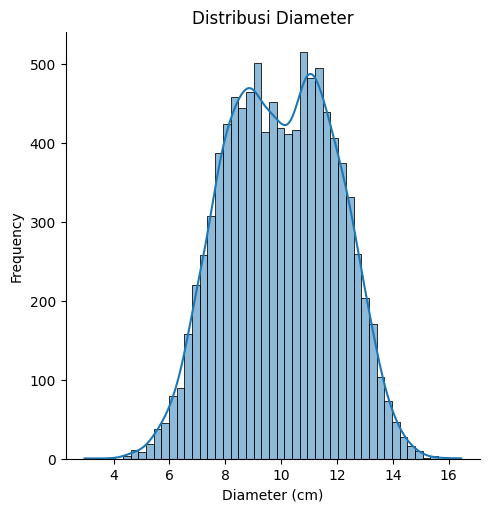

In [ ]:
# Diameter distribution
sns.displot(df['diameter'], kde=True)
plt.title('Distribusi Diameter')
plt.xlabel('Diameter (cm)')
plt.ylabel('Frequency')
plt.show()

**Insight:**
- Distribusi diameter menunjukkan bentuk bimodal (dua puncak), yang mengindikasikan bahwa dua kelas (orange & grapefruit) memiliki rentang diameter yang berbeda namun saling overlap.
- Mayoritas data berada di kisaran 8–12 cm, dengan mean ~9.97 cm.
- Adanya dua puncak memperkuat bahwa fitur diameter cukup diskriminatif untuk membedakan kedua kelas.

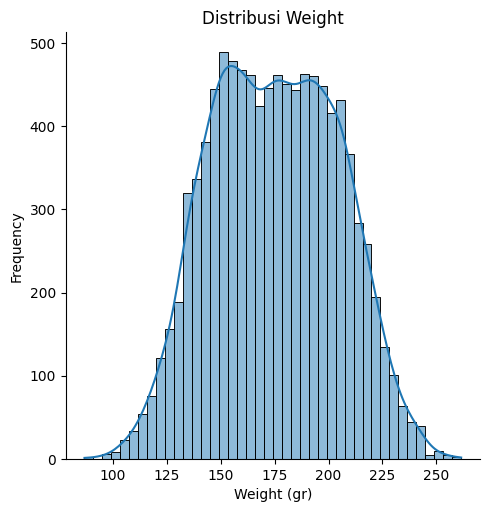

In [ ]:
# Weight distribution
sns.displot(df['weight'], kde=True)
plt.title('Distribusi Weight')
plt.xlabel('Weight (gr)')
plt.ylabel('Frequency')
plt.show()

**Insight:**
- Distribusi berat juga memperlihatkan pola bimodal, konsisten dengan distribusi diameter.
- Rentang berat cukup lebar: 86 gr – 261 gr, dengan mean ~175 gr.
- Bimodal ini mengisyaratkan bahwa grapefruit cenderung lebih berat dibanding orange, sehingga fitur ini juga berpotensi menjadi fitur penting dalam klasifikasi.

In [ ]:
# Label encoding pada kolom name yang merupakan target
le = LabelEncoder()
df['name'] = le.fit_transform(df['name'])
# grapefruit = 0, orange = 1
print('Hasil Label Encoding', dict(zip(['grapefruit', 'orange'], le.transform(['grapefruit', 'orange']))))

Hasil Label Encoding {'grapefruit': np.int64(0), 'orange': np.int64(1)}


In [ ]:
# Correlation matrix
corr_matrix = df.corr()


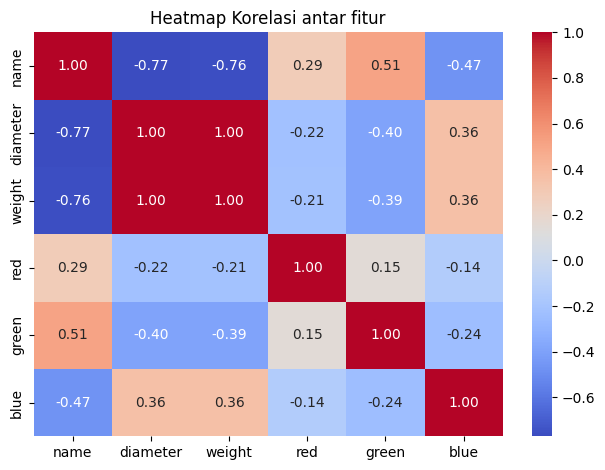

In [ ]:
# Heatmap korelasi
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi antar fitur')
plt.tight_layout()
plt.show()

**Insight:**
- **Korelasi Terhadap Label (name)**
Diameter dan weight memiliki korelasi negatif yang kuat terhadap label (masing-masing -0.77 dan -0.76), artinya semakin besar diameter dan berat buah, semakin besar kemungkinan buah tersebut adalah grapefruit. Kedua fitur ini adalah prediktor terkuat dalam dataset.
Green berkorelasi positif cukup signifikan (+0.51), menunjukkan bahwa grapefruit cenderung memiliki warna yang lebih kehijauan dibanding orange.
Blue berkorelasi negatif sedang (-0.47), mengindikasikan bahwa orange cenderung memiliki komponen warna biru yang lebih dominan.
Red hanya berkorelasi +0.29 terhadap label, menjadikannya fitur yang paling lemah kontribusinya dalam membedakan kedua buah.

- **Korelasi Antar Fitur**
Diameter dan weight memiliki korelasi sempurna sebesar +1.00, yang berarti kedua fitur ini membawa informasi yang hampir identik — semakin besar diameternya, pasti semakin berat pula buahnya, tanpa pengecualian.
Fitur-fitur warna (red, green, blue) cenderung berkorelasi rendah satu sama lain, menunjukkan bahwa setiap channel warna membawa informasi yang relatif independen dan tidak redundan satu sama lain.

**Pembagian Data (Training dan Testing)**

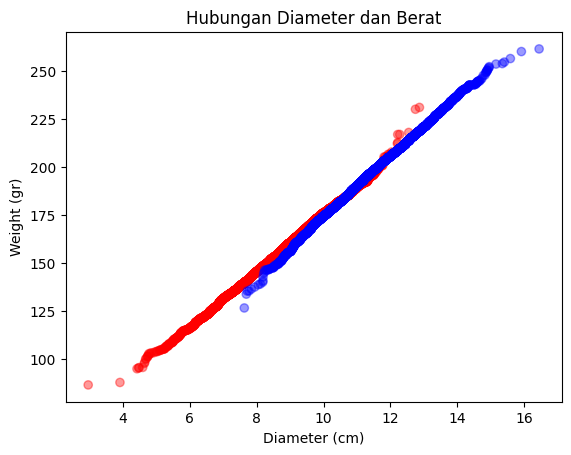

In [ ]:
# Hubungan antara Diameter dan Berat
plt.scatter(df['diameter'], df['weight'], c=df['name'], alpha=0.4, cmap='bwr')
plt.xlabel('Diameter (cm)')
plt.ylabel('Weight (gr)')
plt.title('Hubungan Diameter dan Berat')
plt.show()

In [ ]:
# Split data into independent/dependent variables
X = df[['diameter', 'weight', 'red', 'green', 'blue']].values #fitur
Y = df['name'].values #target: 0=grapefruit, 1=orange

In [ ]:
# Split data into Train/Test sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Print jumlah data train dan data test
print('Jumlah data train:', len(X_train))
print('Jumlah data test:', len(X_test))

Jumlah data train: 8000
Jumlah data test: 2000


In [ ]:
# Scale dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Klasifikasi**

In [ ]:
# Train klasifikasi model Decision Tree
classifier = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
classifier.fit(X_train, Y_train)

SVC(probability=True, random_state=42)

**Report Hasil Klasifikasi**

In [ ]:
# Prediction
Y_pred = classifier.predict(X_test)
print(np.concatenate((Y_pred.reshape(len(Y_pred), 1), Y_test.reshape(len(Y_test), 1)), 1))

# Accuracy
accuracy = accuracy_score(Y_test, Y_pred)
print('Accuracy:', accuracy)

# F1 score
f1 = f1_score(Y_test, Y_pred)
print('F1 Score:', f1)

# Classification report
report = classification_report(Y_test, Y_pred, target_names=['grapefruit', 'orange'])
print('Classification Report:')
print(report)


[[0 0]
 [1 1]
 [1 1]
 ...
 [0 0]
 [1 1]
 [0 0]]
Accuracy: 0.937
F1 Score: 0.9369369369369369
Classification Report:
              precision    recall  f1-score   support

  grapefruit       0.93      0.95      0.94       988
      orange       0.95      0.92      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



**Evaluasi**

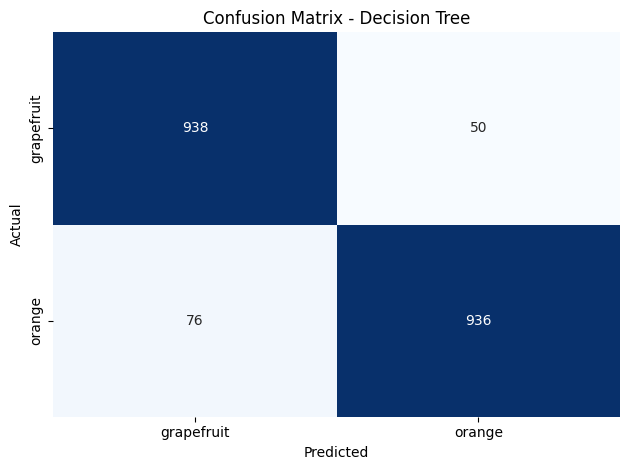

In [ ]:
# Confusion matrix
cf_matrix = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['grapefruit', 'orange'],
            yticklabels=['grapefruit', 'orange'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

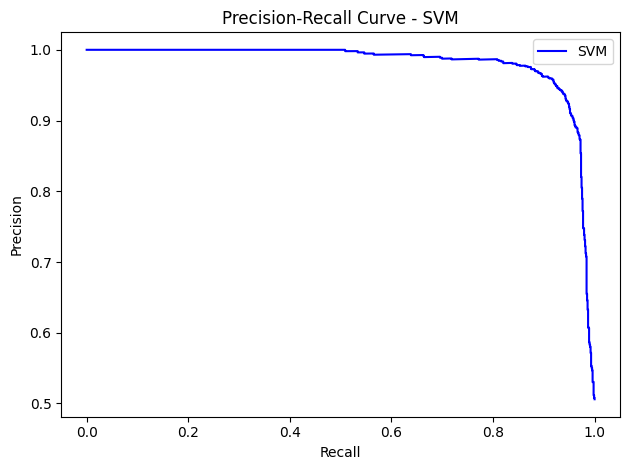

In [ ]:
# Plot Precision-Recall Curve
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(Y_test, y_pred_proba)

fig, ax = plt.subplots()
ax.plot(recall, precision, color='blue', label='SVM')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - SVM')
ax.legend()
plt.tight_layout()
plt.show()

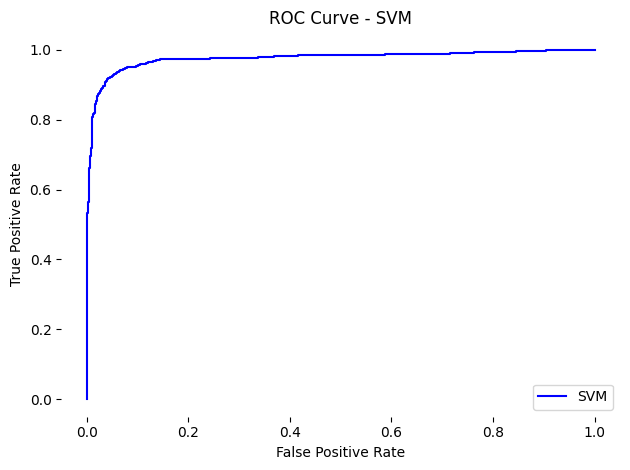

In [ ]:
# Plot AUC/ROC Curve
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(Y_test, y_pred_proba)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, color='blue', label='SVM')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - SVM')
plt.box(False)
ax.legend()
plt.tight_layout()
plt.show()